## Code to generate figure for cell types by organ by crosswalk/tool

## Install and import libraries

In [2]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import lru_cache

import warnings
warnings.filterwarnings("ignore")

## Functions

In [3]:
def load_crosswalk(url: str, source: str):
    df = pd.read_csv(url, skiprows=10)
    df["source"] = source
    return df

In [4]:
@lru_cache(maxsize=None)
def get_label(uberon_id):
    iri = f'http://purl.obolibrary.org/obo/{uberon_id.replace(":", "_")}'
    url = "https://www.ebi.ac.uk/ols4/api/ontologies/uberon/terms"
    resp = requests.get(url, params={"iri": iri}, timeout=30)
    if resp.status_code == 200 and resp.json()["_embedded"]["terms"]:
        return resp.json()["_embedded"]["terms"][0]["label"]
    return None

## Get data

In [5]:
CROSSWALKS = {
    "azimuth": "https://cdn.humanatlas.io/digital-objects/ctann/azimuth/v1.4/assets/azimuth-crosswalk.csv",
    "celltypist": "https://cdn.humanatlas.io/digital-objects/ctann/celltypist/v1.3/assets/celltypist-crosswalk.csv",
    "deepcelltypes": "https://cdn.humanatlas.io/digital-objects/ctann/deepcelltypes/v1.2/assets/deepcelltypes-crosswalk.csv",
    "deepcelltypes_hubmap": "https://cdn.humanatlas.io/digital-objects/ctann/deepcelltypes-hubmap/v1.2/assets/deepcelltypes-hubmap-crosswalk.csv",
    "frmatch": "https://cdn.humanatlas.io/digital-objects/ctann/frmatch/v1.0/assets/frmatch-crosswalk.csv",
    "pan_human_azimuth": "https://cdn.humanatlas.io/digital-objects/ctann/pan-human-azimuth/v1.2/assets/pan-human-azimuth-crosswalk.csv",
    "popv": "https://cdn.humanatlas.io/digital-objects/ctann/popv/v1.4/assets/popv-crosswalk.csv",
    "ribca": "https://cdn.humanatlas.io/digital-objects/ctann/ribca/v1.0/assets/ribca-crosswalk.csv",
    "stellar": "https://cdn.humanatlas.io/digital-objects/ctann/stellar/v1.0/assets/stellar-crosswalk.csv",
    "vccf": "https://cdn.humanatlas.io/digital-objects/ctann/vccf/v1.2/assets/vccf-crosswalk.csv",
}

df_combined = pd.concat(
    [load_crosswalk(url, source) for source, url in CROSSWALKS.items()],
    ignore_index=True,
)
df_combined

,Organ_Level,Organ_ID,Annotation_Label,Annotation_Label_ID,CL_Label,CL_ID,CL_Match,source,Unnamed: 7
0,Heart_L2,UBERON:0000948,Adipocyte,AZ:0000001,adipocyte,CL:0000136,skos:exactMatch,azimuth,NaN
1,Heart_L2,UBERON:0000948,Arterial Endothelial,AZ:0000002,endothelial cell of artery,CL:1000413,skos:exactMatch,azimuth,NaN
2,Heart_L2,UBERON:0000948,Atrial Cardiomyocyte,AZ:0000003,regular atrial cardiac myocyte,CL:0002129,skos:exactMatch,azimuth,NaN
3,Heart_L2,UBERON:0000948,B,AZ:0000004,B cell,CL:0000236,skos:exactMatch,azimuth,NaN
4,Heart_L2,UBERON:0000948,Capillary Endothelial,AZ:0000005,capillary endothelial cell,CL:0002144,skos:exactMatch,azimuth,NaN
...,...,...,...,...,...,...,...,...,...
3461,tonsil-codex-stanford_L3,UBERON:0002372,plasma cell,VCCF:0000496,plasma cell,CL:0000786,skos:exactMatch,vccf,NaN
3462,tonsil-codex-stanford_L3,UBERON:0002372,muscle cell:smooth,VCCF:0000497,smooth muscle cell,CL:0000192,skos:exactMatch,vccf,NaN
3463,tonsil-codex-stanford_L3,UBERON:0002372,squamous epithelial cell,VCCF:0000498,squamous epithelial cell,CL:0000076,skos:exactMatch,vccf,NaN
3464,tonsil-codex-stanford_L3,UBERON:0002372,stromal cell,VCCF:0000499,stromal cell,CL:0000499,skos:exactMatch,vccf,NaN


## Preprocess

In [6]:
# get nunique() cell_label by tool per as_label by sex
df_counts = (
    df_combined.groupby(["source", "Organ_ID"])["CL_Label"]
    .nunique()
    .reset_index(name="n_unique_cell_label")
)

df_counts

,source,Organ_ID,n_unique_cell_label
0,azimuth,UBERON:0000160,12
1,azimuth,UBERON:0000178,77
2,azimuth,UBERON:0000198,9
3,azimuth,UBERON:0000945,16
4,azimuth,UBERON:0000948,36
...,...,...,...
73,vccf,UBERON:0002097,20
74,vccf,UBERON:0002106,20
75,vccf,UBERON:0002371,49
76,vccf,UBERON:0002372,71


In [7]:
SOURCE_LABELS = {
    "azimuth": "Azimuth",
    "celltypist": "CellTypist",
    "deepcelltypes": "deepcelltypes",
    "deepcelltypes_hubmap": "deepcelltypes-HuBMAP",
    "frmatch": "FRMatch",
    "pan_human_azimuth": "Pan-human Azimuth",
    "popv": "popV",
    "ribca": "RIBCA",
    "stellar": "STELLAR",
    "vccf": "VCCF",
}

df_counts["source"] = df_counts["source"].map(SOURCE_LABELS)
df_counts["source"] = pd.Categorical(
    df_counts["source"], categories=list(SOURCE_LABELS.values()), ordered=True
)

In [8]:
df_counts["organ_label"] = df_counts["Organ_ID"].apply(get_label)
df_counts

,source,Organ_ID,n_unique_cell_label,organ_label
0,Azimuth,UBERON:0000160,12,intestine
1,Azimuth,UBERON:0000178,77,blood
2,Azimuth,UBERON:0000198,9,None
3,Azimuth,UBERON:0000945,16,stomach
4,Azimuth,UBERON:0000948,36,heart
...,...,...,...,...
73,VCCF,UBERON:0002097,20,skin of body
74,VCCF,UBERON:0002106,20,spleen
75,VCCF,UBERON:0002371,49,bone marrow
76,VCCF,UBERON:0002372,71,tonsil


## Get counts

In [9]:
result = (
    df_combined.groupby("source", as_index=False)["CL_Label"]
    .nunique()
)

total_row = {
    "source": "ALL",
    "CL_Label": df_combined["CL_Label"].nunique(),
}

result = pd.concat([result, pd.DataFrame([total_row])], ignore_index=True)
result

,source,CL_Label
0,azimuth,487
1,celltypist,443
2,deepcelltypes,29
3,deepcelltypes_hubmap,40
4,frmatch,61
5,pan_human_azimuth,440
6,popv,157
7,ribca,15
8,stellar,25
9,vccf,189


In [10]:
result = (
    df_combined.groupby("source", as_index=False)["Organ_ID"]
    .nunique()
)

total_row = {
    "source": "ALL",
    "Organ_ID": df_combined["Organ_ID"].nunique(),
}

result = pd.concat([result, pd.DataFrame([total_row])], ignore_index=True)
result

,source,Organ_ID
0,azimuth,21
1,celltypist,16
2,deepcelltypes,1
3,deepcelltypes_hubmap,1
4,frmatch,1
5,pan_human_azimuth,1
6,popv,24
7,ribca,1
8,stellar,1
9,vccf,11


## Visualization

ROW_SPACING_SCALE=0.50; BOTTOM_SPACE_SCALE=2.00; figure height=148.16 mm


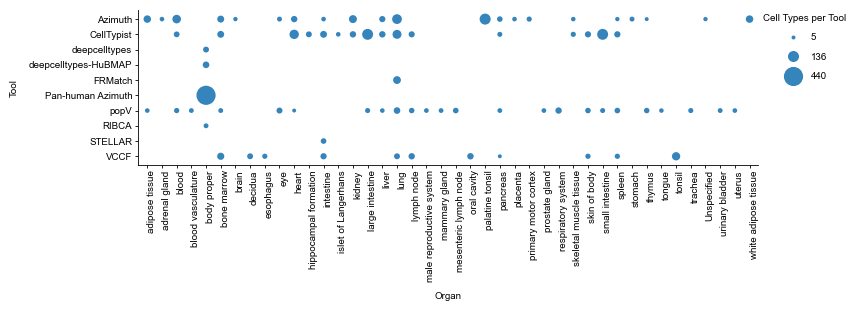

In [11]:
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

SORT_MODE = "alphabetical"
OUTPUT_DIR = Path("outputs/fig-crosswalks-counts-all-10")
FILE_STEM = "fig-crosswalks-counts-all-10_final"

MM_TO_INCH = 1 / 25.4

# =========================
# Adjustable layout controls
# =========================
ROW_SPACING_SCALE = 0.50
BOTTOM_SPACE_SCALE = 2.0   # reserve 2x the current space for organ names
FIGURE_FONT_SIZE = 7.0

# Original layout constants
ORIGINAL_FIGURE_HEIGHT_MM = 135
ORIGINAL_BOTTOM_FRACTION = 0.39
ORIGINAL_TOP_FRACTION = 0.975

# Keep the plotting panel compact, but enlarge the bottom label area.
BOTTOM_MARGIN_MM = (
    ORIGINAL_FIGURE_HEIGHT_MM * ORIGINAL_BOTTOM_FRACTION * BOTTOM_SPACE_SCALE
)
TOP_MARGIN_MM = ORIGINAL_FIGURE_HEIGHT_MM * (1 - ORIGINAL_TOP_FRACTION)
ORIGINAL_PANEL_HEIGHT_MM = (
    ORIGINAL_FIGURE_HEIGHT_MM
    * (ORIGINAL_TOP_FRACTION - ORIGINAL_BOTTOM_FRACTION)
)
PANEL_HEIGHT_MM = ORIGINAL_PANEL_HEIGHT_MM * ROW_SPACING_SCALE
FIGURE_HEIGHT_MM = BOTTOM_MARGIN_MM + PANEL_HEIGHT_MM + TOP_MARGIN_MM

FIGURE_WIDTH_MM = 235
FIGURE_SIZE = (
    FIGURE_WIDTH_MM * MM_TO_INCH,
    FIGURE_HEIGHT_MM * MM_TO_INCH,
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": FIGURE_FONT_SIZE,
    "ytick.labelsize": FIGURE_FONT_SIZE,
    "legend.fontsize": FIGURE_FONT_SIZE,
    "legend.title_fontsize": FIGURE_FONT_SIZE,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ---------- Prepare data ----------
df_plot = df_counts.copy()
df_plot["organ_label"] = (
    df_plot["organ_label"]
    .fillna("Unspecified")
    .astype(str)
    .replace({"None": "Unspecified", "nan": "Unspecified"})
)

tool_order = [
    label for label in SOURCE_LABELS.values()
    if label in set(df_plot["source"].astype(str))
]

organ_summary = (
    df_plot.groupby("organ_label", observed=True)
    .agg(
        n_tools=("source", "nunique"),
        total_cell_types=("n_unique_cell_label", "sum"),
    )
)

if SORT_MODE == "alphabetical":
    organ_order = sorted(organ_summary.index, key=str.casefold)
elif SORT_MODE == "coverage":
    organ_order = (
        organ_summary
        .sort_values(
            ["n_tools", "total_cell_types"],
            ascending=[False, False],
            kind="stable",
        )
        .index
        .tolist()
    )
else:
    raise ValueError("SORT_MODE must be 'alphabetical' or 'coverage'.")

x_position = {organ: i for i, organ in enumerate(organ_order)}
y_position = {tool: i for i, tool in enumerate(tool_order)}

def marker_area(count):
    return 6 + 0.42 * np.asarray(count, dtype=float)

POINT_COLOR = mpl.rcParams["axes.prop_cycle"].by_key()["color"][0]

# ---------- Draw ----------
print(
    f"ROW_SPACING_SCALE={ROW_SPACING_SCALE:.2f}; "
    f"BOTTOM_SPACE_SCALE={BOTTOM_SPACE_SCALE:.2f}; "
    f"figure height={FIGURE_HEIGHT_MM:.2f} mm"
)
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.scatter(
    df_plot["organ_label"].map(x_position),
    df_plot["source"].astype(str).map(y_position),
    s=marker_area(df_plot["n_unique_cell_label"]),
    color=POINT_COLOR,
    alpha=0.90,
    linewidths=0,
)

ax.set_xticks(np.arange(len(organ_order)))
ax.set_xticklabels(
    organ_order,
    rotation=90,
    ha="right",
    va="top",
    fontsize=FIGURE_FONT_SIZE,
    fontfamily="sans-serif",
    rotation_mode="anchor",
)

ax.set_yticks(np.arange(len(tool_order)))
ax.set_yticklabels(
    tool_order,
    fontsize=FIGURE_FONT_SIZE,
    fontfamily="sans-serif",
)

ax.invert_yaxis()
ax.set_xlabel("Organ", labelpad=7)
ax.set_ylabel("Tool", labelpad=7)
ax.set_xlim(-0.6, len(organ_order) - 0.4)
ax.set_ylim(len(tool_order) - 0.4, -0.6)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", pad=1, labelsize=FIGURE_FONT_SIZE)
ax.tick_params(axis="y", pad=2, labelsize=FIGURE_FONT_SIZE)


for label in ax.get_xticklabels():
    label.set_rotation(90)
    label.set_horizontalalignment("right")
    label.set_verticalalignment("top")
    label.set_rotation_mode("anchor")


count_values = df_plot["n_unique_cell_label"].astype(float)
min_count = float(count_values.min())
max_count = float(count_values.max())

midpoint_target = (min_count + max_count) / 2
observed_counts = np.sort(count_values.dropna().unique())
midpoint_count = float(
    observed_counts[np.argmin(np.abs(observed_counts - midpoint_target))]
)

legend_values = [min_count, midpoint_count, max_count]

def format_legend_value(value):
    return f"{value:.0f}" if float(value).is_integer() else f"{value:.1f}"

legend_labels = [
    f"{format_legend_value(legend_values[0])}",
    f"{format_legend_value(legend_values[1])}",
    f"{format_legend_value(legend_values[2])}",
]

legend_handles = [
    ax.scatter(
        [],
        [],
        s=marker_area(value),
        color=POINT_COLOR,
        alpha=0.90,
        linewidths=0,
    )
    for value in legend_values
]

ax.legend(
    legend_handles,
    legend_labels,
    title="Cell Types per Tool",
    fontsize=FIGURE_FONT_SIZE,
    title_fontsize=FIGURE_FONT_SIZE,
    loc="upper left",
    bbox_to_anchor=(1.002, 1.0),
    frameon=False,
    borderaxespad=0,
    labelspacing=1.0,
    handleheight=1.0,
    handletextpad=0.9,
)

fig.subplots_adjust(
    left=0.15,
    right=0.82,
    top=1 - TOP_MARGIN_MM / FIGURE_HEIGHT_MM,
    bottom=BOTTOM_MARGIN_MM / FIGURE_HEIGHT_MM,
)

vis_dir = Path.cwd().parent / "vis"
vis_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    vis_dir / "crosswalk-count-all-10.svg",
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.02,
)
fig.savefig(
    vis_dir / "crosswalk-count-all-10.png",
    dpi=600,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()